In [67]:
from pyspark.sql import SparkSession
from pathlib import Path
from pyspark.sql import functions as F
import country_converter as coco
from itertools import chain

CLEANED_DATA_DIR = Path("../data/cleaned")
PROCESSED_DATA_DIR = Path("../data")

spark = SparkSession.builder.appName("profiling").config("spark.sql.ansi.enabled", "false").config("spark.driver.memory", "16g").getOrCreate()
df = spark.read.parquet(f"{CLEANED_DATA_DIR}/4c_eea_co2_emissions_from_passenger_cars-001.parquet")

df.show(10)

+---+-------------------------------+-----------+-------------+------------------------------------------+--------------------+-------+-------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
|geo|Geopolitical entity (reporting)|TIME_PERIOD|registrations|manufacturer_name_eu_standard_denomination|     commercial_name|variant| Motor energy|mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|
+---+-------------------------------+-----------+-------------+------------------------------------------+--------------------+-------+-------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
| DE|                        Germany|       2023|          254|                                     VOLVO|                XC40|   XZBW|Petrol hybrid|              

In [68]:
motor_energy_color_map = {
    "Electricity": "#2CA02C",               # tab:green
    "Petrol (excluding hybrids)": "#D62728", # tab:red
    "Petrol hybrid": "#FF7F0E",             # tab:orange
    "Diesel (excluding hybrids)": "#1F77B4", # tab:blue
    "Diesel hybrid": "#17BECF",             # tab:cyan
    "Alternative/Other": "#8C564B",         # tab:brown
}

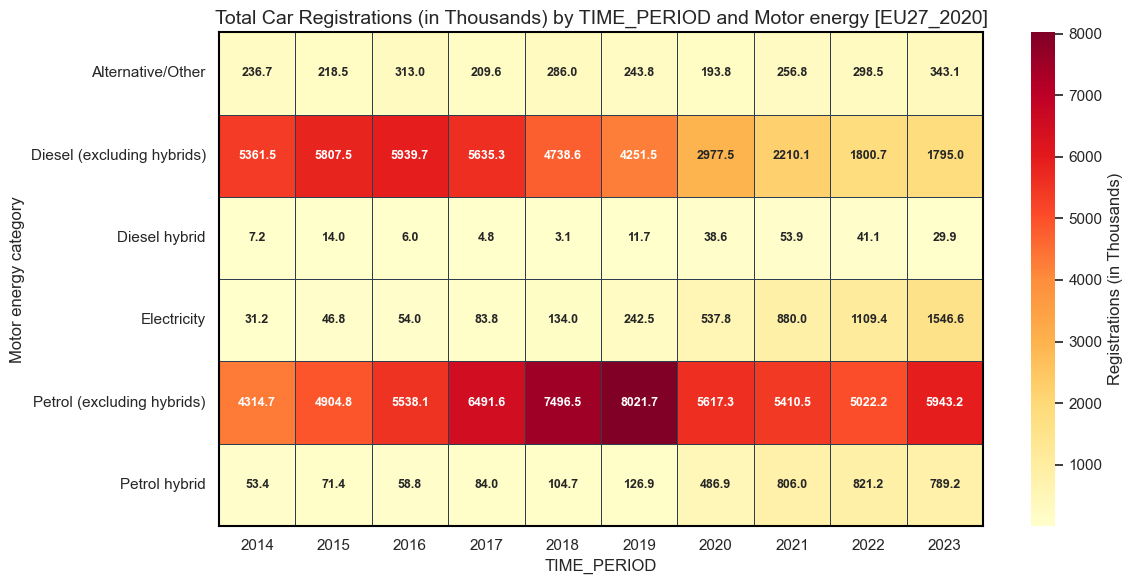

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pivoted_df = (
    df.groupBy("Motor energy")
      .pivot("TIME_PERIOD")
      .agg(F.round(F.sum("registrations") / 1000, 1))
      .fillna(0)
      .orderBy("Motor energy")
)

raw_rows = pivoted_df.collect()
columns = pivoted_df.columns
years = sorted([c for c in columns if c != "Motor energy"])

matrix_dict = {
    r["Motor energy"]: [r[y] for y in years]
    for r in raw_rows
}

heatmap_data = pd.DataFrame.from_dict(matrix_dict, orient="index", columns=years)

plt.figure(figsize=(12, 6))
ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="",
    annot_kws={"weight": "bold", "size": 9},
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="#2c3e50",
    cbar_kws={'label': 'Registrations (in Thousands)'}
)

for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

plt.title("Total Car Registrations (in Thousands) by TIME_PERIOD and Motor energy [EU27_2020]", fontsize=14)
plt.xlabel("TIME_PERIOD")
plt.ylabel("Motor energy category")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("img/powertrain_year_heatmap.png", dpi=300)
plt.show()

In [70]:
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType
from pyspark.sql.window import Window

num_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, NumericType)]

num_summary = (
    df.select(num_cols)
    .summary("count", "mean", "stddev", "min", "50%", "max")
    .toPandas()
    .set_index("summary")
    .T
)

num_summary = num_summary.rename(columns={"50%": "median"}).astype(float).round(2)

display(num_summary)


manufacturer_col = "manufacturer_name_eu_standard_denomination"
commercial_name_col = "commercial_name"

distinct_summary = df.select(
    F.countDistinct(manufacturer_col).alias("manufacturer_unique_count"),
    F.countDistinct(commercial_name_col).alias("commercial_name_unique_count")
).toPandas()

display(distinct_summary)


energy_col = "Motor energy"
registration_col = "registrations"

window_all = Window.partitionBy()

energy_counts = (
    df.groupBy(energy_col)
    .agg(F.sum(registration_col).alias("registrations"))
    .withColumn(
        "percentage (%)", 
        F.round((F.col("registrations") / F.sum("registrations").over(window_all)) * 100, 2)
    )
    .orderBy(F.col("registrations").desc())
    .toPandas()
)

display(energy_counts)

summary,count,mean,stddev,min,median,max
TIME_PERIOD,2194200.0,2019.43,2.62,2014.0,2020.0,2023.0
registrations,2194200.0,50.20,368.36,1.0,3.0,92652.0
mass_in_running_order (kg),2193332.0,1673.42,364.16,205.0,1615.0,5440.0
co2_emissions_WLTP (g/km),2077594.0,151.14,59.16,0.0,151.0,2810.0
engine_capacity (cm3),2103584.0,1901.76,697.85,120.0,1968.0,8382.0
engine_power (KW),2173610.0,136.07,71.92,0.0,110.0,1770.0
electric_energy_consumption (Wh/km),215437.0,195.79,64.18,1.0,182.0,1754.0


,manufacturer_unique_count,commercial_name_unique_count
0,144,31974


,Motor energy,registrations,percentage (%)
0,Petrol (excluding hybrids),58760697,53.34
1,Diesel (excluding hybrids),40517447,36.78
2,Electricity,4666088,4.24
3,Petrol hybrid,3402513,3.09
4,Alternative/Other,2599858,2.36
5,Diesel hybrid,210233,0.19


In [71]:
def print_latex_table(
    df, caption, label, font_size="\\tiny", column_format=None, include_index=False
):
    temp_df = df.copy()

    if include_index:
        index_name = (
            temp_df.index.name if temp_df.index.name else "Variable / Attribute"
        )
        temp_df = temp_df.reset_index()
        temp_df = temp_df.rename(columns={"index": index_name, "summary": index_name})

    temp_df.columns = [f"{col}" for col in temp_df.columns]

    tabular_str = temp_df.to_latex(
        index=False,
        escape=True,
        float_format="%.2f",
        column_format=column_format,
        bold_rows=False,
    )

    tabular_str = (
        tabular_str.replace("\\toprule", "\\hline")
        .replace("\\midrule", "\\hline")
        .replace("\\bottomrule", "\\hline")
    )

    latex_output = f"""\\begin{{table}}[h]
\\centering
{font_size}
\\caption{{{caption}}}
\\label{{{label}}}
{tabular_str.strip()}
\\end{{table}}"""

    print(latex_output)

In [72]:
print_latex_table(
    df=num_summary,
    caption="Summary statistics for numerical attributes in the dataset.",
    label="tab:numerical_summary",
    font_size="\\tiny",
    column_format="p{4.5cm} c c c c c c",
    include_index=True,
)

print_latex_table(
    df=distinct_summary,
    caption="Unique counts for high-cardinality categorical attributes.",
    label="tab:distinct_counts",
    font_size="\\tiny",
    column_format="p{6cm} p{6cm}",
    include_index=False,
)

print_latex_table(
    df=energy_counts,
    caption="Distribution of newly registered passenger cars by motor energy category.",
    label="tab:motor_energy_distribution",
    font_size="\\tiny",
    column_format="p{5cm} r r",
    include_index=False,
)

\begin{table}[h]
\centering
\tiny
\caption{Summary statistics for numerical attributes in the dataset.}
\label{tab:numerical_summary}
\begin{tabular}{p{4.5cm} c c c c c c}
\hline
Variable / Attribute & count & mean & stddev & min & median & max \\
\hline
TIME\_PERIOD & 2194200.00 & 2019.43 & 2.62 & 2014.00 & 2020.00 & 2023.00 \\
registrations & 2194200.00 & 50.20 & 368.36 & 1.00 & 3.00 & 92652.00 \\
mass\_in\_running\_order (kg) & 2193332.00 & 1673.42 & 364.16 & 205.00 & 1615.00 & 5440.00 \\
co2\_emissions\_WLTP (g/km) & 2077594.00 & 151.14 & 59.16 & 0.00 & 151.00 & 2810.00 \\
engine\_capacity (cm3) & 2103584.00 & 1901.76 & 697.85 & 120.00 & 1968.00 & 8382.00 \\
engine\_power (KW) & 2173610.00 & 136.07 & 71.92 & 0.00 & 110.00 & 1770.00 \\
electric\_energy\_consumption (Wh/km) & 215437.00 & 195.79 & 64.18 & 1.00 & 182.00 & 1754.00 \\
\hline
\end{tabular}
\end{table}
\begin{table}[h]
\centering
\tiny
\caption{Unique counts for high-cardinality categorical attributes.}
\label{tab:distinct

In [73]:
df.show(10)

+---+-------------------------------+-----------+-------------+------------------------------------------+--------------------+-------+-------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
|geo|Geopolitical entity (reporting)|TIME_PERIOD|registrations|manufacturer_name_eu_standard_denomination|     commercial_name|variant| Motor energy|mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|
+---+-------------------------------+-----------+-------------+------------------------------------------+--------------------+-------+-------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
| DE|                        Germany|       2023|          254|                                     VOLVO|                XC40|   XZBW|Petrol hybrid|              

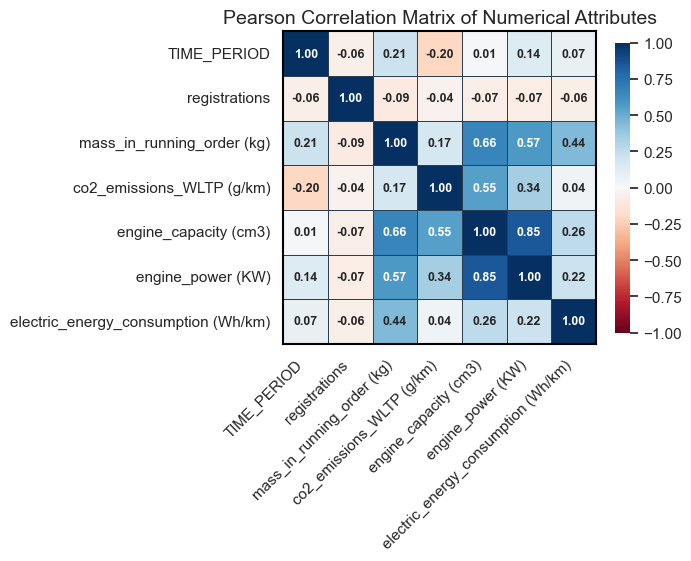

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = [
    "TIME_PERIOD", 
    "registrations", 
    "mass_in_running_order (kg)", 
    "co2_emissions_WLTP (g/km)", 
    "engine_capacity (cm3)", 
    "engine_power (KW)", 
    "electric_energy_consumption (Wh/km)"
]

correlation_matrix = df.select(corr_cols).toPandas().corr()

plt.figure(figsize=(7, 6))
ax = sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    annot_kws={"weight": "bold", "size": 9},
    cmap="RdBu",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="#2c3e50",
    cbar_kws={"shrink": 0.80}
)

# Heatmap border
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

plt.title("Pearson Correlation Matrix of Numerical Attributes", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("img/correlation.png", dpi=300)
plt.show()

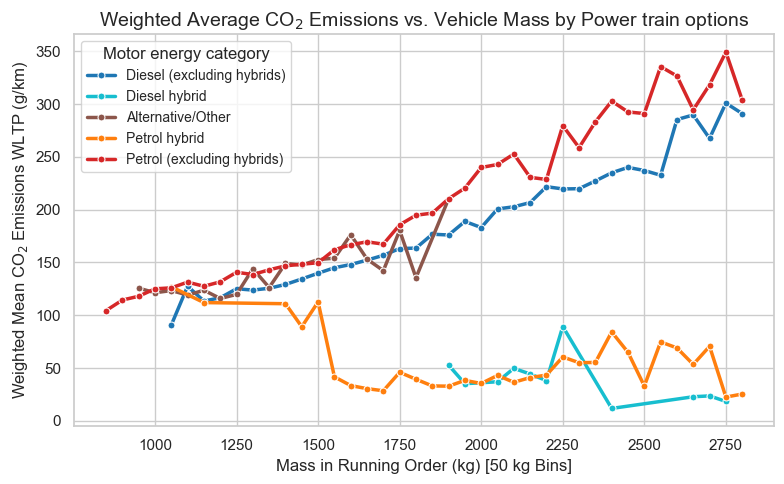

In [75]:
trend_df = (
    df.filter(
        (F.lower(F.col("Motor energy")) != "electricity") & 
        (F.col("co2_emissions_WLTP (g/km)") > 0)
    )
    .withColumn("mass_bin", F.round(F.col("mass_in_running_order (kg)") / 50) * 50)
    .groupBy("mass_bin", "Motor energy")
    .agg(
        (F.sum(F.col("co2_emissions_WLTP (g/km)") * F.col("registrations")) / F.sum("registrations")).alias("weighted_avg_co2"),
        F.sum("registrations").alias("total_registrations")
    )
    # filter outliers
    .filter(F.col("total_registrations") >= 1000)
)

trend_pdf = trend_df.toPandas()

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=trend_pdf,
    x="mass_bin",
    y="weighted_avg_co2",
    hue="Motor energy",
    palette=motor_energy_color_map,
    linewidth=2.5,
    markersize=5,
    marker="o"
)

plt.title("Weighted Average CO$_2$ Emissions vs. Vehicle Mass by Power train options", fontsize=14)
plt.xlabel("Mass in Running Order (kg) [50 kg Bins]")
plt.ylabel("Weighted Mean CO$_2$ Emissions WLTP (g/km)")
plt.legend(title="Motor energy category", fontsize=10, title_fontsize=12)

plt.tight_layout()
plt.savefig("img/bivariate_mass_co2.png", dpi=300)
plt.show()

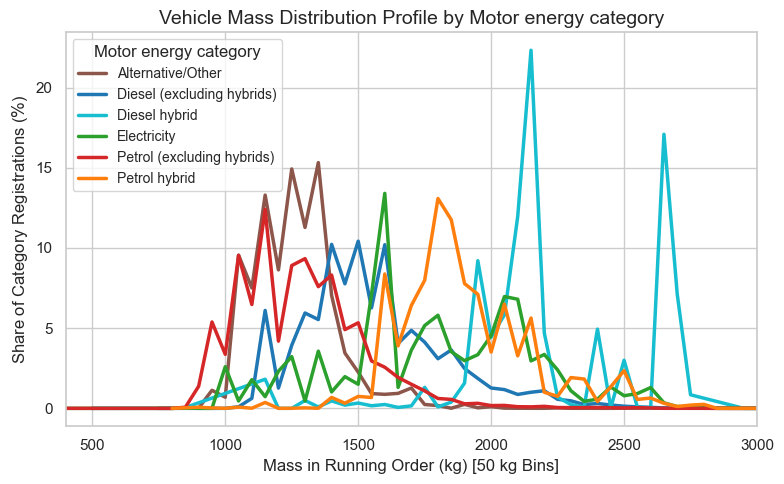

In [76]:
from pyspark.sql.window import Window

binned_df = (
    df.filter(F.col("mass_in_running_order (kg)").isNotNull())
    .withColumn("mass_bin", F.round(F.col("mass_in_running_order (kg)") / 50) * 50)
    .groupBy("Motor energy", "mass_bin")
    .agg(F.sum("registrations").alias("bin_registrations"))
)

window_category = Window.partitionBy("Motor energy")

density_df = (
    binned_df
    .withColumn("total_category_registrations", F.sum("bin_registrations").over(window_category))
    .filter(F.col("total_category_registrations") >= 100)
    .withColumn("density_pct", (F.col("bin_registrations") / F.col("total_category_registrations")) * 100)
)

mass_pdf = density_df.toPandas()

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=mass_pdf,
    x="mass_bin",
    y="density_pct",
    hue="Motor energy",
    palette=motor_energy_color_map,
    linewidth=2.5
)

plt.title("Vehicle Mass Distribution Profile by Motor energy category", fontsize=14)
plt.xlabel("Mass in Running Order (kg) [50 kg Bins]")
plt.ylabel("Share of Category Registrations ($\%$)")
plt.xlim(400, 3000)
plt.legend(title="Motor energy category", fontsize=10, title_fontsize=12)

plt.tight_layout()
plt.savefig("img/bivariate_mass_by_motor_energy_dist.png", dpi=300)
plt.show()

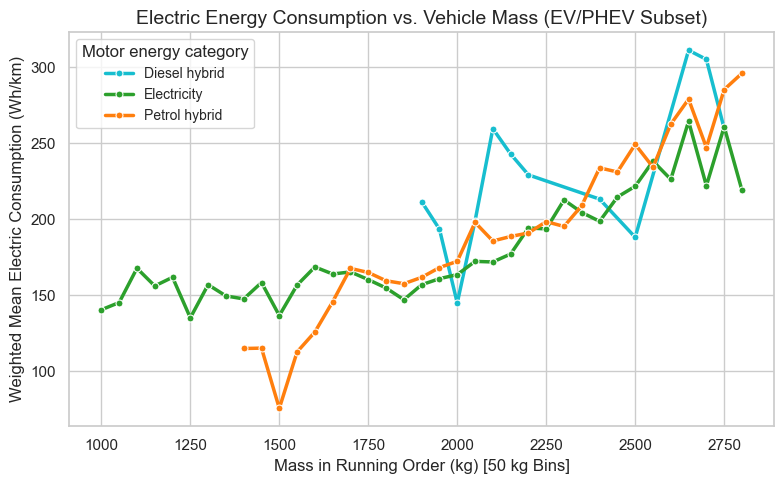

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

ev_phev_categories = [
    "Electricity",
    "Petrol hybrid",
    "Diesel hybrid",
    "Alternative/Other"
]

ev_phev_df = df.filter(
    F.col("Motor energy").isin(ev_phev_categories) &
    F.col("electric_energy_consumption (Wh/km)").isNotNull() &
    (F.col("electric_energy_consumption (Wh/km)") > 0)
)

trend_df = (
    ev_phev_df
    .withColumn("mass_bin", F.round(F.col("mass_in_running_order (kg)") / 50) * 50)
    .groupBy("mass_bin", "Motor energy")
    .agg(
        (
            F.sum(F.col("electric_energy_consumption (Wh/km)") * F.col("registrations")) 
            / F.sum("registrations")
        ).alias("weighted_avg_electric_consumption"),
        F.sum("registrations").alias("total_registrations")
    )
    .filter(F.col("total_registrations") >= 1000)
)

ev_pdf = trend_df.toPandas()

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=ev_pdf,
    x="mass_bin",
    y="weighted_avg_electric_consumption",
    hue="Motor energy",
    palette=motor_energy_color_map,
    linewidth=2.5,
    marker="o",
    markersize=5
)

plt.title("Electric Energy Consumption vs. Vehicle Mass (EV/PHEV Subset)", fontsize=14)
plt.xlabel("Mass in Running Order (kg) [50 kg Bins]")
plt.ylabel("Weighted Mean Electric Consumption (Wh/km)")
plt.legend(title="Motor energy category", fontsize=10, title_fontsize=12)

plt.tight_layout()
plt.savefig("img/bivariate_electric_energy_vs_mass.png", dpi=300)
plt.show()